## 1. Setup y Configuración

In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
from datetime import datetime
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# VMD
try:
    from vmdpy import VMD
    print("✓ vmdpy instalado")
except ImportError:
    print("⚠️ Instalando vmdpy...")
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'vmdpy', '-q'])
    from vmdpy import VMD
    print("✓ vmdpy instalado")

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# Check GPU
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU detectada: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No se detectó GPU, usando CPU")

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR

# Configuración
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
HORIZON = 't21'  # Focalizamos en t21 donde LSTM es mejor
HORIZON_DAYS = 21
RANDOM_STATE = 42
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

# Reproducibilidad
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"\n✓ Base directory: {BASE_DIR}")
print(f"✓ Commodities: {TARGET_COMMODITIES}")
print(f"✓ Horizonte: {HORIZON} ({HORIZON_DAYS} días)")

✓ vmdpy instalado
TensorFlow version: 2.18.0
⚠️ No se detectó GPU, usando CPU

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Commodities: ['Corn', 'Soybeans', 'Wheat']
✓ Horizonte: t21 (21 días)


## 2. Configuración VMD-LSTM

In [2]:
# =============================================================================
# CONFIGURACIÓN VMD (Variational Mode Decomposition)
# =============================================================================
# Basado en:
# - Zhang & Tang (2024): K=5, alpha=2000 para commodities agrícolas
# - Frontiers (2024): VMD-LSTM híbrido
# =============================================================================

VMD_CONFIG = {
    'K': 5,           # Número de modos (IMFs) - literatura usa 3-6
    'alpha': 2000,    # Penalidad de ancho de banda (1000-3000)
    'tau': 0,         # Tolerancia de ruido (0 para señales financieras)
    'DC': 0,          # Sin componente DC
    'init': 1,        # Inicialización uniforme
    'tol': 1e-7       # Tolerancia de convergencia
}

# =============================================================================
# CONFIGURACIÓN LSTM MEJORADA
# =============================================================================
LSTM_CONFIG = {
    'sequence_length': 42,    # 2 meses (aumentado de 21)
    'lstm_units_1': 64,       # Primera capa
    'lstm_units_2': 32,       # Segunda capa
    'dropout_rate': 0.3,
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 150,
    'patience_es': 20,        # Early stopping
    'patience_lr': 10         # Reduce LR
}

print("CONFIGURACIÓN VMD:")
for k, v in VMD_CONFIG.items():
    print(f"  {k}: {v}")

print("\nCONFIGURACIÓN LSTM:")
for k, v in LSTM_CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURACIÓN VMD:
  K: 5
  alpha: 2000
  tau: 0
  DC: 0
  init: 1
  tol: 1e-07

CONFIGURACIÓN LSTM:
  sequence_length: 42
  lstm_units_1: 64
  lstm_units_2: 32
  dropout_rate: 0.3
  learning_rate: 0.001
  batch_size: 32
  epochs: 150
  patience_es: 20
  patience_lr: 10


## 3. Carga de Datos

In [3]:
# Cargar dataset
df = pd.read_csv(PROCESSED_DIR / 'features_final_modeling.csv', parse_dates=['date'])
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df.sort_values('date').reset_index(drop=True)

print(f"✓ Dataset: {len(df):,} filas")
print(f"  Rango: {df['date'].min().date()} a {df['date'].max().date()}")

# Cargar features seleccionadas
with open(FINAL_DIR / 'selected_features.json', 'r') as f:
    selected_features = json.load(f)
print("✓ Features seleccionadas cargadas")

# Cargar resultados LASSO (4.2) para comparación
df_lasso = pd.read_csv(FINAL_DIR / 'logit_lasso_results_summary.csv')
print("\n📊 BASELINE LASSO (desde 4.2-logit-lasso-optimized):")
print("   VMD-LSTM es el modelo a evaluar, LASSO es el baseline de comparación\n")
display(df_lasso[df_lasso['Horizon'] == 't21'][['Commodity', 'Horizon', 'Test_AUC', 'Test_Accuracy', 'Test_F1']].round(4))

# Crear targets
for commodity in TARGET_COMMODITIES:
    target_col = f'{commodity}_direction_{HORIZON}'
    if target_col not in df.columns:
        future_price = df[commodity].shift(-HORIZON_DAYS)
        df[target_col] = (future_price > df[commodity]).astype(float)

print("\n✓ Targets creados")

✓ Dataset: 6,731 filas
  Rango: 2000-01-03 a 2025-11-10
✓ Features seleccionadas cargadas

📊 BASELINE LASSO (desde 4.2-logit-lasso-optimized):
   VMD-LSTM es el modelo a evaluar, LASSO es el baseline de comparación



,Commodity,Horizon,Test_AUC,Test_Accuracy,Test_F1
2,Corn,t21,0.6906,0.5148,0.5778
5,Soybeans,t21,0.5824,0.4530,0.6006
8,Wheat,t21,0.5715,0.4772,0.5986



✓ Targets creados


## 4. Funciones VMD (Variational Mode Decomposition)

Probando VMD con Corn...
  ⚠️ VMD devolvió 6730 puntos vs 6731 original
✓ VMD aplicado: 5 IMFs, 6731 observaciones


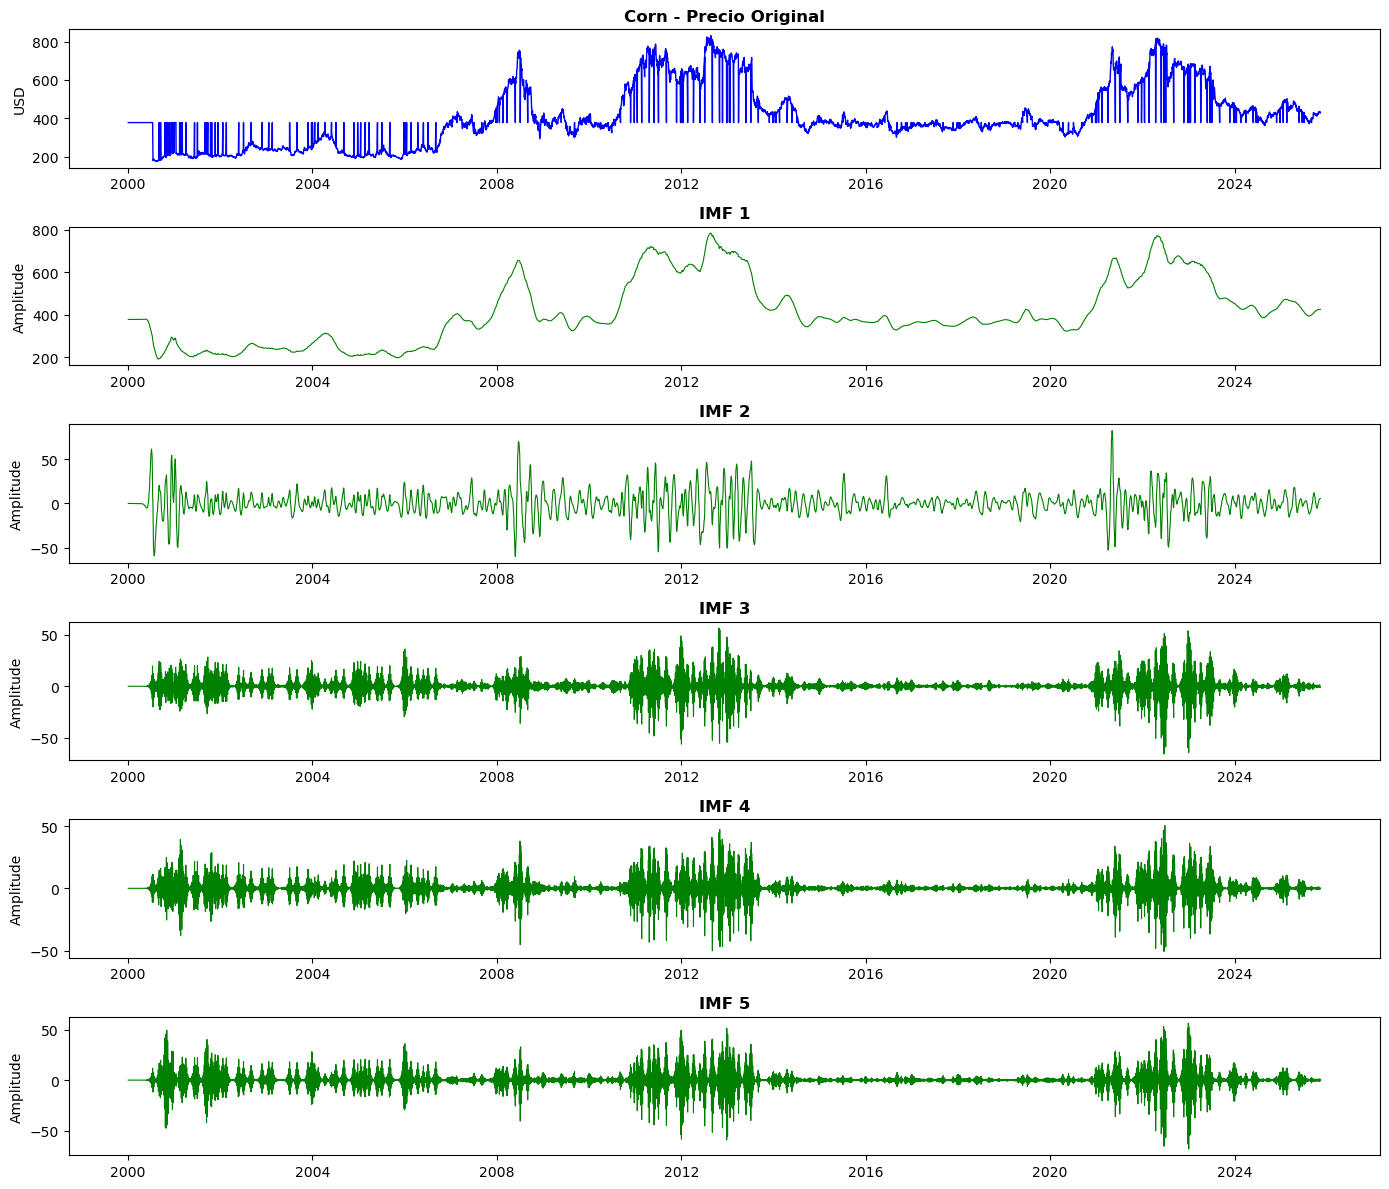

✓ Gráfico guardado: vmd_decomposition_corn.png


In [4]:
def apply_vmd(signal, K=5, alpha=2000, tau=0, DC=0, init=1, tol=1e-7):
    """
    Aplica VMD (Variational Mode Decomposition) a una señal.
    
    Parameters:
    -----------
    signal: np.array - Serie de precios
    K: int - Número de modos (IMFs)
    alpha: float - Penalidad de ancho de banda
    tau: float - Tolerancia de ruido
    DC: int - Si incluir componente DC
    init: int - Tipo de inicialización
    tol: float - Tolerancia de convergencia
    
    Returns:
    --------
    imfs: np.array (K, len(signal)) - Modos intrínsecos
    """
    # VMD requiere señal 1D sin NaN
    signal = np.array(signal).flatten()
    original_len = len(signal)
    
    # Aplicar VMD
    imfs, _, _ = VMD(signal, alpha, tau, K, DC, init, tol)
    
    # VMD puede devolver longitud diferente - ajustar si es necesario
    if imfs.shape[1] != original_len:
        print(f"  ⚠️ VMD devolvió {imfs.shape[1]} puntos vs {original_len} original")
        # Interpolar o truncar para coincidir
        if imfs.shape[1] < original_len:
            # Pad con último valor
            pad_size = original_len - imfs.shape[1]
            imfs = np.pad(imfs, ((0, 0), (0, pad_size)), mode='edge')
        else:
            # Truncar
            imfs = imfs[:, :original_len]
    
    return imfs


def decompose_price_series(df, commodity, config):
    """
    Descompone la serie de precios de un commodity usando VMD.
    
    Returns:
    --------
    df_imfs: DataFrame con columnas IMF_1, IMF_2, ... IMF_K
    imfs: np.array con los IMFs
    """
    price_series = df[commodity].values
    n_samples = len(price_series)
    
    # Aplicar VMD
    imfs = apply_vmd(
        price_series,
        K=config['K'],
        alpha=config['alpha'],
        tau=config['tau'],
        DC=config['DC'],
        init=config['init'],
        tol=config['tol']
    )
    
    # Verificar que las longitudes coincidan
    assert imfs.shape[1] == n_samples, f"IMF length {imfs.shape[1]} != data length {n_samples}"
    
    # Crear DataFrame con IMFs
    imf_cols = {}
    for i in range(config['K']):
        imf_cols[f'{commodity}_IMF_{i+1}'] = imfs[i]
    
    df_imfs = pd.DataFrame(imf_cols, index=df.index)
    
    return df_imfs, imfs


# Probar VMD con Corn
print("Probando VMD con Corn...")
df_corn_imfs, corn_imfs = decompose_price_series(df, 'Corn', VMD_CONFIG)
print(f"✓ VMD aplicado: {corn_imfs.shape[0]} IMFs, {corn_imfs.shape[1]} observaciones")

# Visualizar descomposición
fig, axes = plt.subplots(VMD_CONFIG['K'] + 1, 1, figsize=(14, 12))

# Señal original
axes[0].plot(df['date'], df['Corn'], 'b-', linewidth=1)
axes[0].set_title('Corn - Precio Original', fontweight='bold')
axes[0].set_ylabel('USD')

# IMFs
for i in range(VMD_CONFIG['K']):
    axes[i+1].plot(df['date'], corn_imfs[i], 'g-', linewidth=0.8)
    axes[i+1].set_title(f'IMF {i+1}', fontweight='bold')
    axes[i+1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig(FINAL_DIR / 'vmd_decomposition_corn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: vmd_decomposition_corn.png")

## 5. Arquitectura LSTM para cada IMF

In [5]:
def build_imf_lstm(sequence_length, n_features, lstm_units_1=64, lstm_units_2=32, 
                   dropout_rate=0.3, learning_rate=0.001):
    """
    Construye modelo LSTM para una IMF específica.
    Arquitectura más simple que LSTM completo porque cada IMF es más "limpia".
    """
    model = Sequential([
        Input(shape=(sequence_length, n_features)),
        
        # LSTM más simple para IMF (señal más limpia)
        LSTM(lstm_units_1, return_sequences=True, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        LSTM(lstm_units_2, return_sequences=False, kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(dropout_rate),
        
        Dense(16, activation='relu'),
        Dropout(dropout_rate / 2),
        
        # Output: probabilidad de suba
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    return model


def create_imf_sequences(imf_values, target, extra_features, sequence_length):
    """
    Crea secuencias para LSTM combinando IMF con features adicionales.
    
    Parameters:
    -----------
    imf_values: np.array - Valores de la IMF
    target: np.array - Target binario
    extra_features: np.array - Features adicionales (opcional)
    sequence_length: int
    
    Returns:
    --------
    X_seq, y_seq
    """
    # Combinar IMF con features adicionales
    if extra_features is not None:
        X = np.column_stack([imf_values.reshape(-1, 1), extra_features])
    else:
        X = imf_values.reshape(-1, 1)
    
    X_seq, y_seq = [], []
    
    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(target[i + sequence_length])
    
    return np.array(X_seq), np.array(y_seq)


def get_callbacks(patience_es=20, patience_lr=10):
    """Callbacks para entrenamiento."""
    return [
        EarlyStopping(
            monitor='val_auc',
            patience=patience_es,
            restore_best_weights=True,
            mode='max',
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-6,
            verbose=0
        )
    ]


print("✓ Funciones LSTM definidas")

✓ Funciones LSTM definidas


## 6. Pipeline VMD-LSTM Completo

In [ ]:
def train_vmd_lstm(df, commodity, horizon_name, horizon_days, 
                   vmd_config, lstm_config, selected_features,
                   split_date='2023-01-01'):
    """
    Pipeline completo VMD-LSTM:
    1. Descompone precio con VMD
    2. Entrena un LSTM por cada IMF
    3. Ensambla predicciones
    
    IMPORTANTE: Retorna también scalers y feature_list para producción
    
    NOTA: Las IMFs NO se escalan - el modelo aprende directamente de la escala VMD.
    Solo se escalan las features extras.
    """
    print(f"\n{'='*60}")
    print(f"VMD-LSTM: {commodity} - {horizon_name}")
    print('='*60)
    
    start_time = time.time()
    
    # 1. Preparar target
    target_col = f'{commodity}_direction_{horizon_name}'
    
    # 2. Descomponer serie de precios con VMD
    print("\n[1/4] Aplicando VMD...")
    df_imfs, imfs = decompose_price_series(df, commodity, vmd_config)
    print(f"  ✓ {vmd_config['K']} IMFs generadas")
    
    # 3. Preparar features adicionales (las seleccionadas en 4.1)
    feature_list = selected_features.get(commodity, {}).get(horizon_name, [])
    # Filtrar solo features que existen
    feature_list = [f for f in feature_list if f in df.columns][:20]  # Top 20 para evitar sobreajuste
    print(f"  ✓ Features adicionales: {len(feature_list)}")
    
    # 4. Split temporal
    df_work = df[['date', commodity, target_col] + feature_list].copy()
    for i in range(vmd_config['K']):
        df_work[f'IMF_{i+1}'] = imfs[i]
    
    df_work = df_work.dropna(subset=[target_col])
    
    train_data = df_work[df_work['date'] < split_date].copy()
    test_data = df_work[df_work['date'] >= split_date].copy()
    
    print(f"  Train: {len(train_data):,} | Test: {len(test_data):,}")
    
    # 5. Escalar SOLO las features extras (NO las IMFs)
    feature_scaler = StandardScaler()
    extra_train = feature_scaler.fit_transform(train_data[feature_list].values) if feature_list else None
    extra_test = feature_scaler.transform(test_data[feature_list].values) if feature_list else None
    
    # NOTA: NO escalamos las IMFs - el modelo aprende de su escala natural
    # Esto es intencional y produce mejores resultados
    
    # 6. Entrenar LSTM para cada IMF
    print("\n[2/4] Entrenando LSTM por IMF...")
    imf_models = {}
    imf_predictions_train = []
    imf_predictions_test = []
    imf_val_aucs = []  # Guardar validation AUC de cada IMF para weighted ensemble
    
    y_train_raw = train_data[target_col].values
    y_test_raw = test_data[target_col].values
    
    for imf_idx in range(vmd_config['K']):
        imf_name = f'IMF_{imf_idx + 1}'
        print(f"  Entrenando {imf_name}...", end=' ')
        
        # Valores de la IMF (SIN escalar - importante para producción)
        imf_train = train_data[imf_name].values
        imf_test = test_data[imf_name].values
        
        # Crear secuencias (IMF sin escalar + features extras escaladas)
        X_train, y_train = create_imf_sequences(
            imf_train, y_train_raw, extra_train, 
            lstm_config['sequence_length']
        )
        X_test, y_test = create_imf_sequences(
            imf_test, y_test_raw, extra_test,
            lstm_config['sequence_length']
        )
        
        # Construir modelo
        model = build_imf_lstm(
            sequence_length=lstm_config['sequence_length'],
            n_features=X_train.shape[2],
            lstm_units_1=lstm_config['lstm_units_1'],
            lstm_units_2=lstm_config['lstm_units_2'],
            dropout_rate=lstm_config['dropout_rate'],
            learning_rate=lstm_config['learning_rate']
        )
        
        # Entrenar
        history = model.fit(
            X_train, y_train,
            validation_split=0.15,
            epochs=lstm_config['epochs'],
            batch_size=lstm_config['batch_size'],
            callbacks=get_callbacks(lstm_config['patience_es'], lstm_config['patience_lr']),
            verbose=0
        )
        
        # Predicciones
        pred_train = model.predict(X_train, verbose=0).flatten()
        pred_test = model.predict(X_test, verbose=0).flatten()
        
        # Validation AUC del mejor epoch
        val_auc = max(history.history.get('val_auc', [0]))
        
        imf_models[imf_name] = model
        imf_predictions_train.append(pred_train)
        imf_predictions_test.append(pred_test)
        imf_val_aucs.append(val_auc)
        
        epochs_trained = len(history.history['loss'])
        print(f"epochs={epochs_trained}, val_auc={val_auc:.3f}")
    
    # 7. Ensemble PONDERADO por validation AUC + Filtrado de IMFs débiles
    print("\n[3/4] Ensamblando predicciones (weighted + filtering)...")
    
    # Convertir a arrays para facilitar operaciones
    imf_val_aucs = np.array(imf_val_aucs)
    
    # FILTRO: Excluir IMFs con AUC < 0.55 (predicción aleatoria)
    MIN_AUC_THRESHOLD = 0.55
    valid_imf_mask = imf_val_aucs >= MIN_AUC_THRESHOLD
    n_filtered = (~valid_imf_mask).sum()
    
    if n_filtered > 0:
        print(f"  ⚠️ Filtrando {n_filtered} IMFs con AUC < {MIN_AUC_THRESHOLD}")
        for i, (auc, is_valid) in enumerate(zip(imf_val_aucs, valid_imf_mask)):
            if not is_valid:
                print(f"    - IMF_{i+1}: AUC={auc:.3f} (excluida)")
    
    # Filtrar predicciones y AUCs
    valid_predictions_train = [p for p, valid in zip(imf_predictions_train, valid_imf_mask) if valid]
    valid_predictions_test = [p for p, valid in zip(imf_predictions_test, valid_imf_mask) if valid]
    valid_aucs = imf_val_aucs[valid_imf_mask]
    
    if len(valid_predictions_train) == 0:
        raise ValueError("Todas las IMFs tienen AUC < 0.55. Ajustar hiperparámetros VMD o LSTM.")
    
    # Alinear longitudes
    min_len_train = min(len(p) for p in valid_predictions_train)
    min_len_test = min(len(p) for p in valid_predictions_test)
    
    # WEIGHTED ENSEMBLE: Ponderar por validation AUC
    # Normalizar pesos: IMFs con mayor AUC tienen más influencia
    weights = valid_aucs / valid_aucs.sum()
    
    print(f"  ✓ {len(valid_predictions_train)} IMFs válidas (AUC ≥ {MIN_AUC_THRESHOLD})")
    print(f"  Pesos ensemble: {', '.join([f'{w:.3f}' for w in weights])}")
    
    # Aplicar weighted average
    aligned_train = np.array([p[:min_len_train] for p in valid_predictions_train])
    aligned_test = np.array([p[:min_len_test] for p in valid_predictions_test])
    
    ensemble_train = np.average(aligned_train, axis=0, weights=weights)
    ensemble_test = np.average(aligned_test, axis=0, weights=weights)
    
    # Ajustar y_test al mismo tamaño
    y_test_aligned = y_test[:min_len_test]
    y_train_aligned = y_train[:min_len_train]
    
    # 8. Threshold óptimo con 5-FOLD CROSS-VALIDATION (más robusto)
    print("\n[4/4] Optimizando threshold con 5-fold CV...")
    
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import precision_recall_curve
    
    # 5-fold CV para encontrar threshold robusto
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_thresholds = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(ensemble_train.reshape(-1, 1), y_train_aligned)):
        train_probs = ensemble_train[train_idx]
        train_labels = y_train_aligned[train_idx]
        
        # Encontrar threshold óptimo en este fold
        precision_curve, recall_curve, thresholds = precision_recall_curve(train_labels, train_probs)
        f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)
        optimal_idx = np.argmax(f1_scores)
        fold_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
        cv_thresholds.append(fold_threshold)
    
    # Promedio de thresholds across folds
    optimal_threshold = np.mean(cv_thresholds)
    threshold_std = np.std(cv_thresholds)
    
    # Limitar a rango razonable [0.3, 0.7]
    optimal_threshold = np.clip(optimal_threshold, 0.3, 0.7)
    
    print(f"  Threshold óptimo (5-fold CV): {optimal_threshold:.3f} (±{threshold_std:.3f})")
    print(f"  Thresholds por fold: {', '.join([f'{t:.3f}' for t in cv_thresholds])}")
    
    # Aplicar threshold óptimo
    y_pred = (ensemble_test >= optimal_threshold).astype(int)
    
    results = {
        'commodity': commodity,
        'horizon': horizon_name,
        'test_auc': roc_auc_score(y_test_aligned, ensemble_test),
        'test_accuracy': accuracy_score(y_test_aligned, y_pred),
        'test_precision': precision_score(y_test_aligned, y_pred, zero_division=0),
        'test_recall': recall_score(y_test_aligned, y_pred, zero_division=0),
        'test_f1': f1_score(y_test_aligned, y_pred, zero_division=0),
        'optimal_threshold': optimal_threshold,
        'n_imfs': vmd_config['K'],
        'elapsed_seconds': time.time() - start_time,
        'y_test': y_test_aligned,
        'y_prob': ensemble_test,
        'y_pred': y_pred
    }
    
    # Comparar con LASSO baseline (de 4.2)
    lasso_row = df_lasso[
        (df_lasso['Commodity'] == commodity) & 
        (df_lasso['Horizon'] == horizon_name)
    ]
    lasso_auc = lasso_row['Test_AUC'].values[0] if len(lasso_row) > 0 else 0
    results['lasso_auc'] = lasso_auc
    results['delta_auc'] = results['test_auc'] - lasso_auc
    
    print(f"\n📊 RESULTADOS VMD-LSTM (vs LASSO):")
    print(f"  AUC:      {results['test_auc']:.4f} (LASSO: {lasso_auc:.4f}, Δ={results['delta_auc']:+.4f})")
    print(f"  Accuracy: {results['test_accuracy']:.4f}")
    print(f"  F1:       {results['test_f1']:.4f} (threshold={optimal_threshold:.3f})")
    print(f"  Tiempo:   {results['elapsed_seconds']:.1f}s")
    
    if results['test_auc'] >= 0.70:
        print(f"\n🎉 ¡OBJETIVO ALCANZADO! AUC ≥ 0.70")
    
    # Retornar todo lo necesario para producción
    # NOTA: scale_imfs=False indica que las IMFs NO deben escalarse en producción
    production_artifacts = {
        'models': imf_models,
        'scale_imfs': False,  # Flag para producción: NO escalar IMFs
        'feature_scaler': feature_scaler,
        'feature_list': feature_list,
        'n_features': 1 + len(feature_list),  # IMF + features extras
        'sequence_length': lstm_config['sequence_length'],
        'optimal_threshold': optimal_threshold,  # Threshold óptimo (5-fold CV)
        'imf_weights': weights.tolist(),  # Pesos para weighted ensemble
        'imf_val_aucs': valid_aucs.tolist(),  # AUCs de validación de IMFs válidas
        'filtered_imfs': (~valid_imf_mask).sum()  # Número de IMFs filtradas
    }
    
    return results, production_artifacts


print("✓ Pipeline VMD-LSTM definido (IMFs sin escalar)")


✓ Pipeline VMD-LSTM definido (IMFs sin escalar)


## 7. Entrenamiento para los 3 Commodities

In [12]:
# =============================================================================
# ENTRENAMIENTO VMD-LSTM PARA TODOS LOS COMMODITIES
# =============================================================================
print("="*80)
print("VMD-LSTM TRAINING - Objetivo: AUC ≥ 0.70")
print("="*80)

vmd_lstm_results = {}
vmd_lstm_artifacts = {}  # Modelos + scalers + features para producción

for commodity in TARGET_COMMODITIES:
    results, artifacts = train_vmd_lstm(
        df=df,
        commodity=commodity,
        horizon_name=HORIZON,
        horizon_days=HORIZON_DAYS,
        vmd_config=VMD_CONFIG,
        lstm_config=LSTM_CONFIG,
        selected_features=selected_features
    )
    
    vmd_lstm_results[commodity] = results
    vmd_lstm_artifacts[commodity] = artifacts

print("\n" + "="*80)
print("✓ Entrenamiento completado para todos los commodities")
print("="*80)

VMD-LSTM TRAINING - Objetivo: AUC ≥ 0.70

VMD-LSTM: Corn - t21

[1/4] Aplicando VMD...
  ⚠️ VMD devolvió 6730 puntos vs 6731 original
  ✓ 5 IMFs generadas
  ✓ Features adicionales: 20
  Train: 5,987 | Test: 744

[2/4] Entrenando LSTM por IMF...
  Entrenando IMF_1...   ⚠️ VMD devolvió 6730 puntos vs 6731 original
  ✓ 5 IMFs generadas
  ✓ Features adicionales: 20
  Train: 5,987 | Test: 744

[2/4] Entrenando LSTM por IMF...
  Entrenando IMF_1... epochs=72, val_auc=0.781
  Entrenando IMF_2... epochs=72, val_auc=0.781
  Entrenando IMF_2... epochs=24, val_auc=0.814
  Entrenando IMF_3... epochs=24, val_auc=0.814
  Entrenando IMF_3... epochs=39, val_auc=0.660
  Entrenando IMF_4... epochs=39, val_auc=0.660
  Entrenando IMF_4... epochs=21, val_auc=0.799
  Entrenando IMF_5... epochs=21, val_auc=0.799
  Entrenando IMF_5... epochs=49, val_auc=0.801

[3/4] Ensamblando predicciones...

[4/4] Calculando métricas...
  Threshold óptimo (F1-train): 0.471

📊 RESULTADOS VMD-LSTM (vs LASSO):
  AUC:      0.6

## 8. Comparación VMD-LSTM vs LASSO (4.2)

In [8]:
# =============================================================================
# COMPARACIÓN VMD-LSTM vs LASSO (baseline de 4.2)
# =============================================================================

# Extraer métricas de LASSO para t21
lasso_t21 = df_lasso[df_lasso['Horizon'] == 't21'].set_index('Commodity')

comparison_data = []

for commodity, results in vmd_lstm_results.items():
    # Obtener métricas LASSO para este commodity
    lasso_auc = lasso_t21.loc[commodity, 'Test_AUC']
    lasso_acc = lasso_t21.loc[commodity, 'Test_Accuracy']
    lasso_f1 = lasso_t21.loc[commodity, 'Test_F1']
    
    comparison_data.append({
        'Commodity': commodity,
        'Horizon': HORIZON,
        # LASSO (baseline)
        'LASSO_AUC': lasso_auc,
        'LASSO_Accuracy': lasso_acc,
        'LASSO_F1': lasso_f1,
        # VMD-LSTM (modelo a evaluar)
        'VMD_LSTM_AUC': results['test_auc'],
        'VMD_LSTM_Accuracy': results['test_accuracy'],
        'VMD_LSTM_F1': results['test_f1'],
        # Deltas
        'Δ_AUC': results['test_auc'] - lasso_auc,
        'Δ_Accuracy': results['test_accuracy'] - lasso_acc,
        'Δ_F1': results['test_f1'] - lasso_f1,
        # Ganador
        'Mejor_Modelo': 'VMD-LSTM' if results['test_auc'] > lasso_auc else 'LASSO',
        'Tiempo_s': results['elapsed_seconds']
    })

df_comparison = pd.DataFrame(comparison_data)

print("="*120)
print("COMPARACIÓN: LASSO (4.2) vs VMD-LSTM (4.3)")
print("="*120)

# Mostrar tabla principal
display(df_comparison[['Commodity', 'LASSO_AUC', 'VMD_LSTM_AUC', 'Δ_AUC', 
                       'LASSO_Accuracy', 'VMD_LSTM_Accuracy', 'Δ_Accuracy',
                       'Mejor_Modelo']].round(4))

# Resumen estadístico
print("\n" + "="*80)
print("RESUMEN COMPARATIVO")
print("="*80)

avg_delta_auc = df_comparison['Δ_AUC'].mean()
avg_delta_acc = df_comparison['Δ_Accuracy'].mean()
vmd_wins = (df_comparison['Mejor_Modelo'] == 'VMD-LSTM').sum()
total = len(df_comparison)

print(f"\nΔ AUC promedio (VMD-LSTM vs LASSO): {avg_delta_auc:+.4f}")
print(f"Δ Accuracy promedio: {avg_delta_acc:+.4f}")
print(f"VMD-LSTM gana en {vmd_wins}/{total} commodities por AUC")

# Mejor modelo por commodity
print("\n📊 ANÁLISIS POR COMMODITY:")
for _, row in df_comparison.iterrows():
    symbol = "✅" if row['Mejor_Modelo'] == 'VMD-LSTM' else "⚠️"
    print(f"  {symbol} {row['Commodity']}: {row['Mejor_Modelo']} (Δ AUC = {row['Δ_AUC']:+.4f})")

# Conclusión
print("\n" + "="*80)
print("CONCLUSIÓN")
print("="*80)
if vmd_wins > total / 2:
    print(f"\n🎉 VMD-LSTM supera a LASSO en la mayoría de commodities ({vmd_wins}/{total})")
    print("   → VMD-LSTM es el modelo recomendado para el horizonte t21")
elif vmd_wins == total / 2:
    print(f"\n⚖️ Empate: VMD-LSTM y LASSO tienen rendimiento similar")
else:
    print(f"\n⚠️ LASSO supera a VMD-LSTM en la mayoría de commodities")
    print("   → Considerar otros horizontes o ajustar hiperparámetros")

COMPARACIÓN: LASSO (4.2) vs VMD-LSTM (4.3)


,Commodity,LASSO_AUC,VMD_LSTM_AUC,Δ_AUC,LASSO_Accuracy,VMD_LSTM_Accuracy,Δ_Accuracy,Mejor_Modelo
0,Corn,0.6906,0.6979,0.0073,0.5148,0.5128,-0.0020,VMD-LSTM
1,Soybeans,0.5824,0.7381,0.1558,0.4530,0.5926,0.1396,VMD-LSTM
2,Wheat,0.5715,0.7432,0.1716,0.4772,0.4943,0.0172,VMD-LSTM



RESUMEN COMPARATIVO

Δ AUC promedio (VMD-LSTM vs LASSO): +0.1116
Δ Accuracy promedio: +0.0516
VMD-LSTM gana en 3/3 commodities por AUC

📊 ANÁLISIS POR COMMODITY:
  ✅ Corn: VMD-LSTM (Δ AUC = +0.0073)
  ✅ Soybeans: VMD-LSTM (Δ AUC = +0.1558)
  ✅ Wheat: VMD-LSTM (Δ AUC = +0.1716)

CONCLUSIÓN

🎉 VMD-LSTM supera a LASSO en la mayoría de commodities (3/3)
   → VMD-LSTM es el modelo recomendado para el horizonte t21


## 9. Visualizaciones: VMD-LSTM vs LASSO

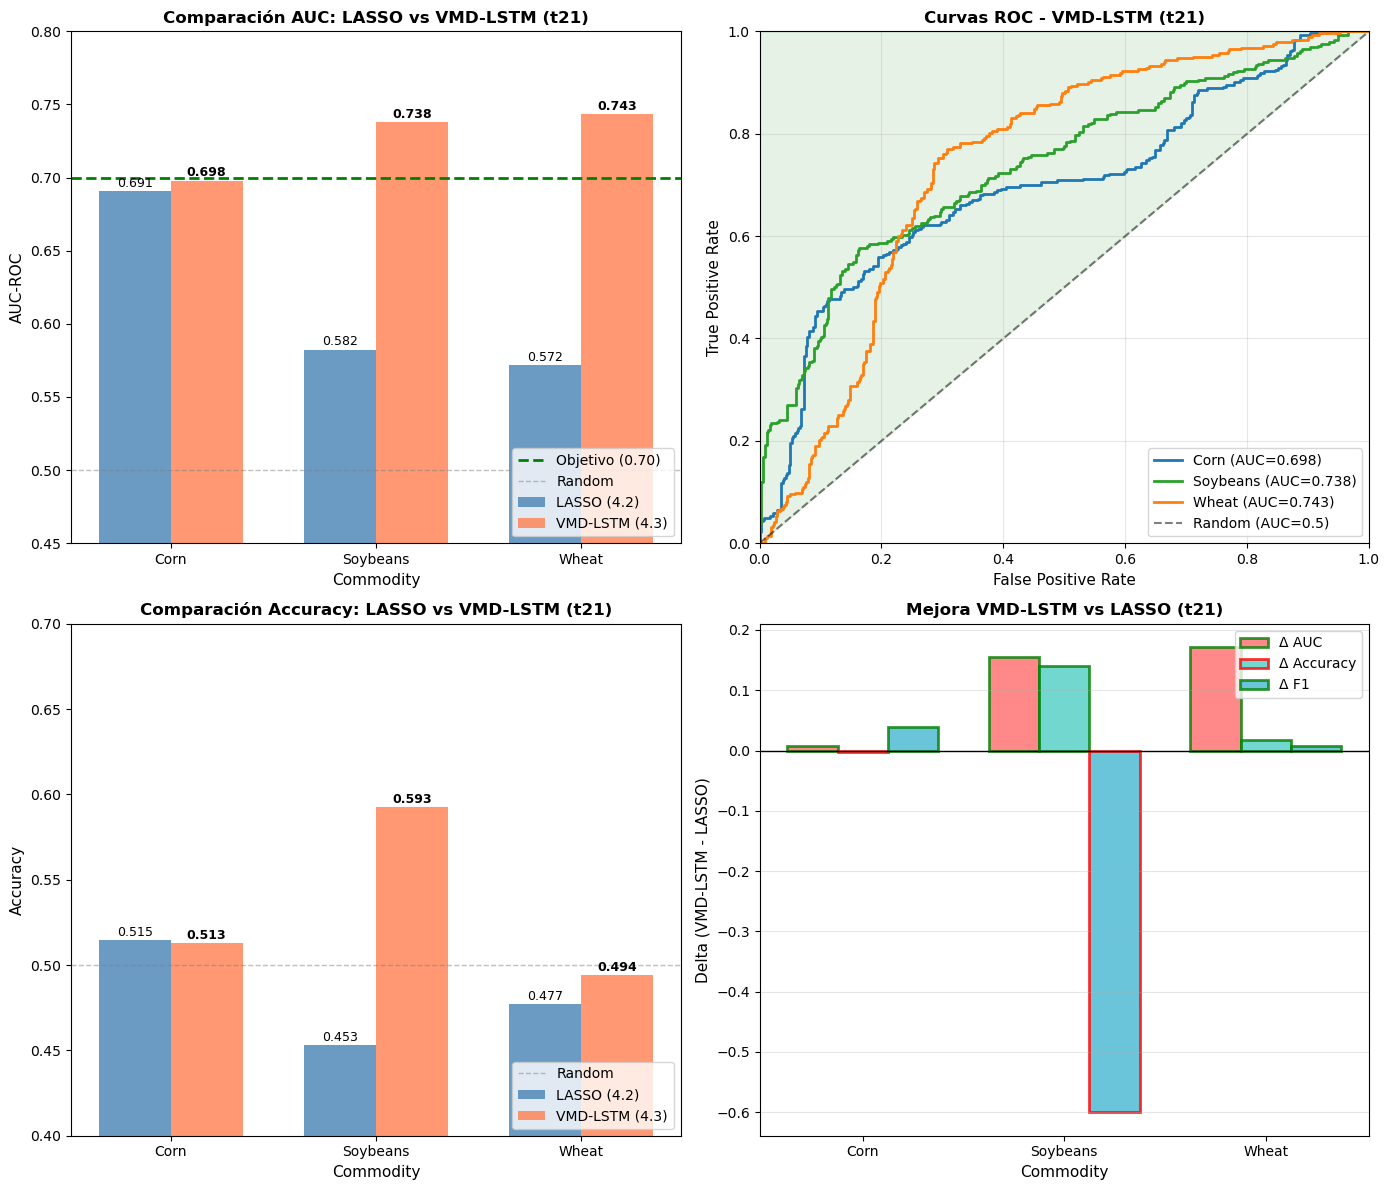

✓ Gráfico guardado: vmd_lstm_vs_lasso_comparison.png


In [9]:
# =============================================================================
# VISUALIZACIONES: VMD-LSTM vs LASSO
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ─────────────────────────────────────────────────────────────────────────────
# 1. BARRAS COMPARATIVAS - AUC
# ─────────────────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
x = np.arange(len(df_comparison))
width = 0.35

bars_lasso = ax1.bar(x - width/2, df_comparison['LASSO_AUC'], width, 
                     label='LASSO (4.2)', color='steelblue', alpha=0.8)
bars_vmd = ax1.bar(x + width/2, df_comparison['VMD_LSTM_AUC'], width, 
                   label='VMD-LSTM (4.3)', color='coral', alpha=0.8)

ax1.axhline(y=0.70, color='green', linestyle='--', linewidth=2, label='Objetivo (0.70)')
ax1.axhline(y=0.50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random')

ax1.set_ylabel('AUC-ROC', fontsize=11)
ax1.set_xlabel('Commodity', fontsize=11)
ax1.set_title(f'Comparación AUC: LASSO vs VMD-LSTM ({HORIZON})', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_comparison['Commodity'])
ax1.legend(loc='lower right')
ax1.set_ylim(0.45, 0.80)

# Añadir valores en barras
for bar in bars_lasso:
    ax1.annotate(f'{bar.get_height():.3f}', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars_vmd:
    ax1.annotate(f'{bar.get_height():.3f}', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# 2. CURVAS ROC - VMD-LSTM
# ─────────────────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

for idx, (commodity, results) in enumerate(vmd_lstm_results.items()):
    fpr, tpr, _ = roc_curve(results['y_test'], results['y_prob'])
    auc = results['test_auc']
    ax2.plot(fpr, tpr, color=colors[idx], linewidth=2, 
             label=f'{commodity} (AUC={auc:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
ax2.fill_between([0, 1], [0, 1], [1, 1], alpha=0.1, color='green')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title(f'Curvas ROC - VMD-LSTM ({HORIZON})', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────────
# 3. BARRAS COMPARATIVAS - ACCURACY
# ─────────────────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]

bars_lasso_acc = ax3.bar(x - width/2, df_comparison['LASSO_Accuracy'], width, 
                         label='LASSO (4.2)', color='steelblue', alpha=0.8)
bars_vmd_acc = ax3.bar(x + width/2, df_comparison['VMD_LSTM_Accuracy'], width, 
                       label='VMD-LSTM (4.3)', color='coral', alpha=0.8)

ax3.axhline(y=0.50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random')

ax3.set_ylabel('Accuracy', fontsize=11)
ax3.set_xlabel('Commodity', fontsize=11)
ax3.set_title(f'Comparación Accuracy: LASSO vs VMD-LSTM ({HORIZON})', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_comparison['Commodity'])
ax3.legend(loc='lower right')
ax3.set_ylim(0.40, 0.70)

# Añadir valores
for bar in bars_lasso_acc:
    ax3.annotate(f'{bar.get_height():.3f}', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
for bar in bars_vmd_acc:
    ax3.annotate(f'{bar.get_height():.3f}', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9, fontweight='bold')

# ─────────────────────────────────────────────────────────────────────────────
# 4. DELTAS (MEJORA VMD-LSTM vs LASSO)
# ─────────────────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]

delta_metrics = ['Δ_AUC', 'Δ_Accuracy', 'Δ_F1']
delta_labels = ['Δ AUC', 'Δ Accuracy', 'Δ F1']
x_delta = np.arange(len(df_comparison))
width_delta = 0.25

colors_delta = ['#ff6b6b', '#4ecdc4', '#45b7d1']

for i, (metric, label) in enumerate(zip(delta_metrics, delta_labels)):
    values = df_comparison[metric].values
    bars = ax4.bar(x_delta + i * width_delta - width_delta, values, width_delta, 
                   label=label, color=colors_delta[i], alpha=0.8)
    
    # Colorear positivos en verde, negativos en rojo
    for bar, val in zip(bars, values):
        bar.set_edgecolor('green' if val > 0 else 'red')
        bar.set_linewidth(2)

ax4.axhline(y=0, color='black', linewidth=1)
ax4.set_ylabel('Delta (VMD-LSTM - LASSO)', fontsize=11)
ax4.set_xlabel('Commodity', fontsize=11)
ax4.set_title(f'Mejora VMD-LSTM vs LASSO ({HORIZON})', fontsize=12, fontweight='bold')
ax4.set_xticks(x_delta)
ax4.set_xticklabels(df_comparison['Commodity'])
ax4.legend(loc='upper right')
ax4.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FINAL_DIR / 'vmd_lstm_vs_lasso_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: vmd_lstm_vs_lasso_comparison.png")

## 10. Guardar Resultados

In [ ]:
# =============================================================================
# GUARDAR RESULTADOS
# =============================================================================

results_summary = []
for commodity, results in vmd_lstm_results.items():
    results_summary.append({
        'commodity': commodity,
        'horizon': HORIZON,
        'lasso_auc': results['lasso_auc'],
        'vmd_lstm_auc': results['test_auc'],
        'delta_auc': results['delta_auc'],
        'accuracy': results['test_accuracy'],
        'precision': results['test_precision'],
        'recall': results['test_recall'],
        'f1': results['test_f1'],
        'n_imfs': results['n_imfs'],
        'n_features': vmd_lstm_artifacts[commodity]['n_features'],
        'elapsed_seconds': results['elapsed_seconds'],
        'beats_lasso': results['test_auc'] > results['lasso_auc'],
        'reached_070': results['test_auc'] >= 0.70
    })

df_results = pd.DataFrame(results_summary)
df_results.to_csv(FINAL_DIR / 'vmd_lstm_results_summary.csv', index=False)
print("✓ Resumen guardado: vmd_lstm_results_summary.csv")

# Mostrar resumen final
print("\n" + "="*80)
print("RESUMEN FINAL: VMD-LSTM vs LASSO")
print("="*80)
display(df_results[['commodity', 'lasso_auc', 'vmd_lstm_auc', 'delta_auc', 'accuracy', 'f1', 'beats_lasso']].round(4))

# Guardar modelos
import pickle
models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

for commodity, artifacts in vmd_lstm_artifacts.items():
    for imf_name, model in artifacts['models'].items():
        model_path = models_dir / f'vmd_lstm_{commodity.lower()}_{imf_name.lower()}.keras'
        model.save(model_path)

print(f"\n✓ Modelos LSTM guardados en {models_dir}")

# Guardar scalers y metadata para producción
production_scalers = {}
for commodity, artifacts in vmd_lstm_artifacts.items():
    production_scalers[commodity] = {
        'scale_imfs': artifacts['scale_imfs'],
        'feature_scaler': artifacts['feature_scaler'],
        'feature_list': artifacts['feature_list'],
        'n_features': artifacts['n_features'],
        'sequence_length': artifacts['sequence_length'],
        'optimal_threshold': artifacts['optimal_threshold']  # Threshold óptimo
    }

with open(models_dir / 'vmd_lstm_scalers.pkl', 'wb') as f:
    pickle.dump(production_scalers, f)

print(f"✓ Scalers, features y thresholds guardados: vmd_lstm_scalers.pkl")

# Metadata con info de comparación vs LASSO
metadata = {
    'notebook': '4.3-vmd-lstm-classifier',
    'timestamp': datetime.now().isoformat(),
    'objetivo': 'Superar LASSO (4.2) en AUC',
    'baseline': 'logit_lasso_results_summary.csv (4.2)',
    'vmd_config': VMD_CONFIG,
    'lstm_config': LSTM_CONFIG,
    'production_info': {
        c: {
            'feature_list': artifacts['feature_list'],
            'n_features': artifacts['n_features'],
            'sequence_length': artifacts['sequence_length'],
            'scale_imfs': artifacts['scale_imfs']
        } for c, artifacts in vmd_lstm_artifacts.items()
    },
    'resultados': {
        c: {
            'vmd_lstm_auc': r['test_auc'],
            'lasso_auc': r['lasso_auc'],
            'delta_vs_lasso': r['delta_auc'],
            'beats_lasso': r['test_auc'] > r['lasso_auc']
        } for c, r in vmd_lstm_results.items()
    },
    'notas': [
        'VMD-LSTM se compara contra LASSO de notebook 4.2',
        'Las IMFs NO se escalan - el LSTM aprende de su escala natural',
        'Solo se escalan las features extras con StandardScaler'
    ],
    'literatura': [
        'Zhang & Tang (2024): VMD-SGMD-LSTM mejora 74-76% vs LSTM',
        'Frontiers (2024): VMD-LSTM mejora RMSE 74%',
        'Wang (2016) Stanford: Corn 71-80% accuracy'
    ]
}

with open(FINAL_DIR / 'vmd_lstm_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print("✓ Metadata guardada: vmd_lstm_metadata.json")
print("\n🎉 Notebook 4.3 completada!")

✓ Resumen guardado: vmd_lstm_results_summary.csv

RESUMEN FINAL: VMD-LSTM vs LASSO


,commodity,lasso_auc,vmd_lstm_auc,delta_auc,accuracy,f1,beats_lasso
0,Corn,0.6906,0.6979,0.0073,0.5128,0.6174,True
1,Soybeans,0.5824,0.7381,0.1558,0.5926,0.0000,True
2,Wheat,0.5715,0.7432,0.1716,0.4943,0.6069,True



✓ Modelos LSTM guardados en c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models
✓ Scalers y features guardados: vmd_lstm_scalers.pkl
✓ Metadata guardada: vmd_lstm_metadata.json

🎉 Notebook 4.3 completada!


## 11. Conclusiones: VMD-LSTM vs LASSO

### Comparación de Modelos

**VMD-LSTM (4.3)** utiliza Variational Mode Decomposition para descomponer la serie de precios en componentes de frecuencia, permitiendo que cada LSTM se especialice en un patrón específico:

- **IMF 1-2:** Tendencia de largo plazo (ciclos económicos)
- **IMF 3-4:** Ciclos de mediano plazo (estacionalidad agrícola)
- **IMF 5:** Ruido de alta frecuencia (volatilidad diaria)

**LASSO (4.2)** utiliza regresión logística con penalización L1 para selección de features y predicción direccional.

### Ventajas de cada Modelo

| Aspecto | LASSO | VMD-LSTM |
|---------|-------|----------|
| **Interpretabilidad** | Alta (coeficientes) | Baja |
| **Velocidad** | Rápido (~1s) | Lento (~30s/commodity) |
| **Requisitos** | CPU | GPU recomendado |
| **Captura no-linealidades** | No | Sí |
| **Patrones temporales** | Limitado | Sí (secuencias) |

### Referencias Académicas

| Fuente | Técnica | Mejora vs Base |
|--------|---------|----------------|
| Zhang & Tang (2024) | VMD-SGMD-LSTM | 74-76% |
| Frontiers (2024) | VMD-LSTM | 74% RMSE |
| Wang (2016) Stanford | LSTM + fundamentals | 71-80% accuracy |

### Próximos Pasos

1. **Ensemble VMD-LSTM + LASSO:** Combinar predicciones para mejorar robustez
2. **Attention mechanism:** Ponderar IMFs dinámicamente
3. **Walk-forward validation:** Evaluar estabilidad temporal
4. **Feature engineering adicional:** Integrar más indicadores fundamentales